In [2]:
import os
import numpy as np
import pandas as pd
import scipy
import anndata
import scanpy as sc
import pybiomart
import scvi
import torch
import random
import seaborn as sns

In [3]:
def PlotUMAP(adata, markers, layer='log2_counts_scvi', size=2, vmin='p0', vmax='p99'):
    for i in range(len(markers)):
        sc.pl.umap(adata,
                  color=markers[i],
                  layer=layer,
                  size=size,
                  cmap=sns.blend_palette(['lightgray', sns.xkcd_rgb['red orange']], as_cmap=True),
                   vmin=vmin, vmax=vmax)

In [4]:
cwd = os.getcwd()
adata = sc.read_h5ad(cwd+'/outs/231226_trevino_rna_scvi.h5ad')
adata

AnnData object with n_obs × n_vars = 1000 × 13132
    obs: 'Cell.ID', 'Sample.ID', 'Age', 'Tissue.ID', 'Sample.Type', 'Assay', 'Batch', 'seurat_clusters', 'RNA.Counts', 'RNA.Features', 'Percent.MT', 'Percent.Ribo', 'Cell.Barcode', 'DF_pANN', 'DF_classification', 'DF_pANN_quantile', 'Spliced.Counts', 'Spliced.Features', 'Unspliced.Counts', 'Unspliced.Features', 'Ambiguous.Counts', 'Ambiguous.Features', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden_scvi'
    var: 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scvi', 'leiden_scvi_colors', 'neighbors_scvi', 'umap'
    obsm: 'X_scvi', 'X_umap'
    layers: 'counts', 'counts_scvi'
    obsp: 'neighbors_scvi_connectivities', 'neighbors_scvi_distances'

In [5]:
adata.layers['log2_counts'] = sc.pp.log1p(adata.layers['counts'].copy(), base=2)
adata.layers['log2_counts_scvi'] = sc.pp.log1p(adata.layers['counts_scvi'].copy(), base=2)

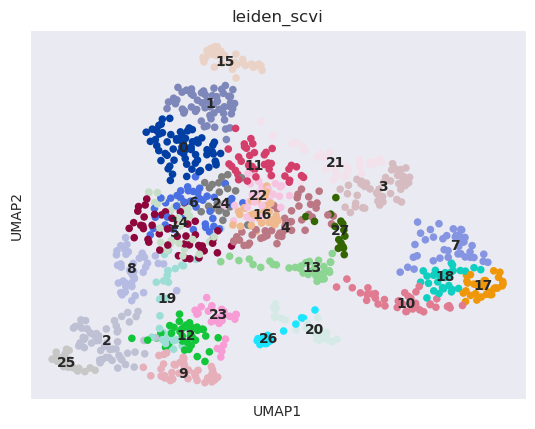

In [6]:
sc.pl.umap(adata, color=['leiden_scvi'], legend_loc='on data')

In [7]:
adata.obs

,Cell.ID,Sample.ID,Age,Tissue.ID,Sample.Type,Assay,Batch,seurat_clusters,RNA.Counts,RNA.Features,...,Spliced.Counts,Spliced.Features,Unspliced.Counts,Unspliced.Features,Ambiguous.Counts,Ambiguous.Features,n_genes,_scvi_batch,_scvi_labels,leiden_scvi
hft_w16_p7_r2_TGCACGGGTAGATTAG,hft_w16_p7_r2_TGCACGGGTAGATTAG,hft_w16_p7_r2,pcw16,HFT7,HFT,RNA NG,b2020_03,c2,3673,1640,...,2581,1267,1481,827,365,219,1623,1,0,24
hft_w21_p5_r1_AGTTGGTAGGGTCGAT,hft_w21_p5_r1_AGTTGGTAGGGTCGAT,hft_w21_p5_r1,pcw21,HFT5,HFT,RNA v3,b2020_02,c12,5706,2527,...,4020,1956,3336,1556,649,391,2496,4,0,1
hft_w20_p3_r1_GAAATGAGTAATGTGA,hft_w20_p3_r1_GAAATGAGTAATGTGA,hft_w20_p3_r1,pcw20,HFT3,HFT,RNA v3,b2019_06,c18,10666,3570,...,7747,2778,5266,2290,1049,616,3471,2,0,19
hft_w21_p5_r1_CTAAGACTCGCCCTTA,hft_w21_p5_r1_CTAAGACTCGCCCTTA,hft_w21_p5_r1,pcw21,HFT5,HFT,RNA v3,b2020_02,c17,4793,2190,...,3297,1631,3632,1639,560,396,2155,4,0,23
hft_w24_p6_r2_ATTTACCGTCAACACT,hft_w24_p6_r2_ATTTACCGTCAACACT,hft_w24_p6_r2,pcw24,HFT6,HFT,RNA NG,b2020_02,c0,4855,2050,...,3470,1567,2837,1458,499,315,2021,7,0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hft_w16_p7_r2_TTCACCGGTGTAAATG,hft_w16_p7_r2_TTCACCGGTGTAAATG,hft_w16_p7_r2,pcw16,HFT7,HFT,RNA NG,b2020_03,c9,1930,882,...,1511,726,102,83,136,104,876,1,0,13
hft_w21_p5_r2_CGACCTTAGGATTCGG,hft_w21_p5_r2_CGACCTTAGGATTCGG,hft_w21_p5_r2,pcw21,HFT5,HFT,RNA v3,b2020_02,c1,2820,1351,...,1923,1010,1697,1002,302,208,1331,5,0,18
hft_w16_p7_r2_ACCGTTCTCGACACTA,hft_w16_p7_r2_ACCGTTCTCGACACTA,hft_w16_p7_r2,pcw16,HFT7,HFT,RNA NG,b2020_03,c13,760,537,...,475,360,2307,1053,120,100,524,1,0,3
hft_w24_p6_r2_GGGACAAAGTCATACC,hft_w24_p6_r2_GGGACAAAGTCATACC,hft_w24_p6_r2,pcw24,HFT6,HFT,RNA NG,b2020_02,c10,7716,3105,...,5479,2405,3710,1677,859,511,3045,7,0,9


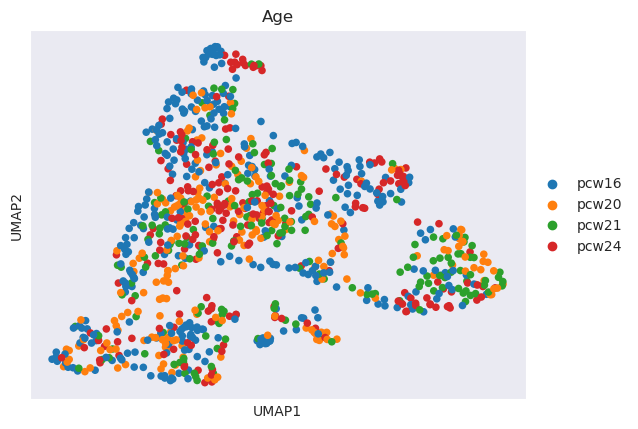

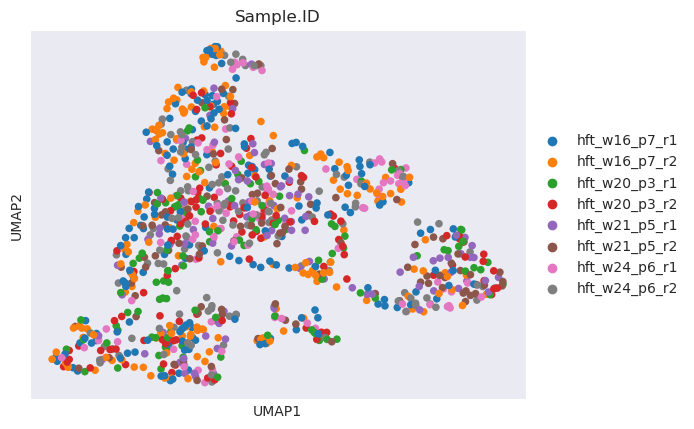

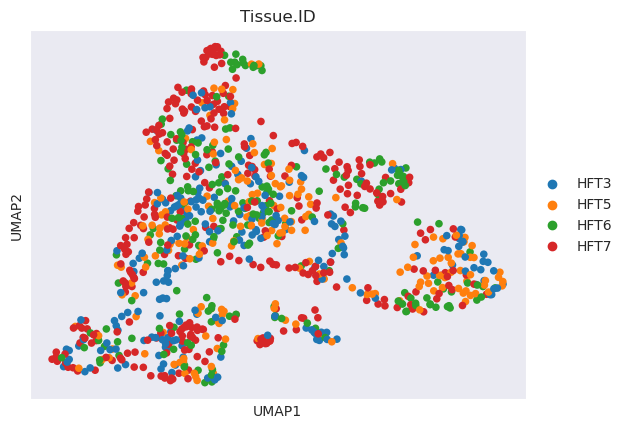

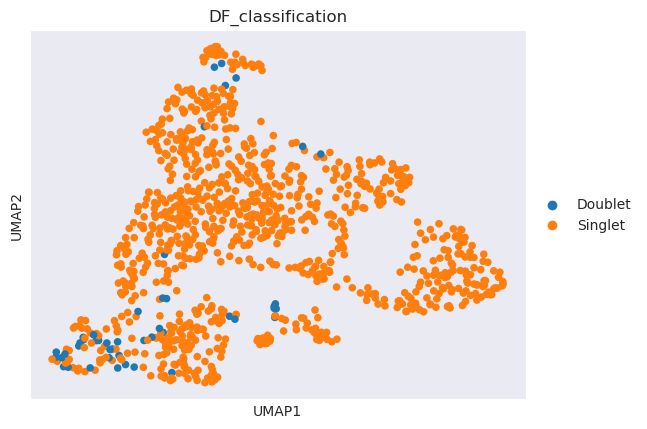

In [8]:
sc.pl.umap(adata, color=['Age'])
sc.pl.umap(adata, color=['Sample.ID'])
sc.pl.umap(adata, color=['Tissue.ID'])
sc.pl.umap(adata, color=['DF_classification'])

In [9]:
adata.var_names_make_unique()

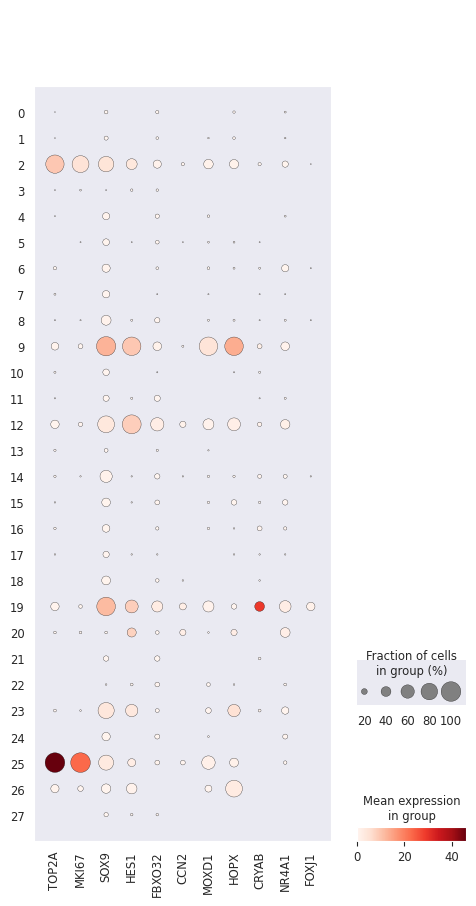

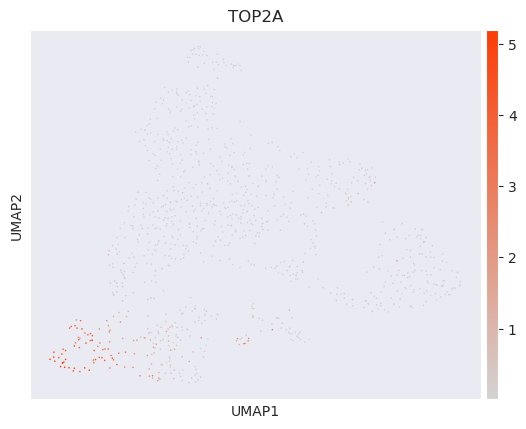

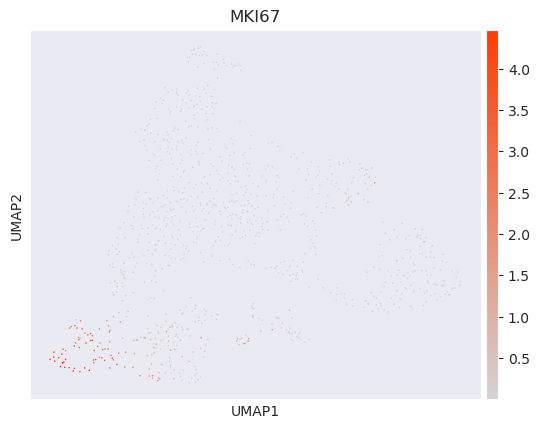

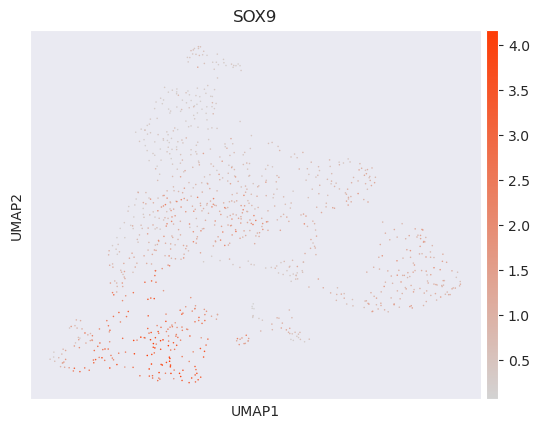

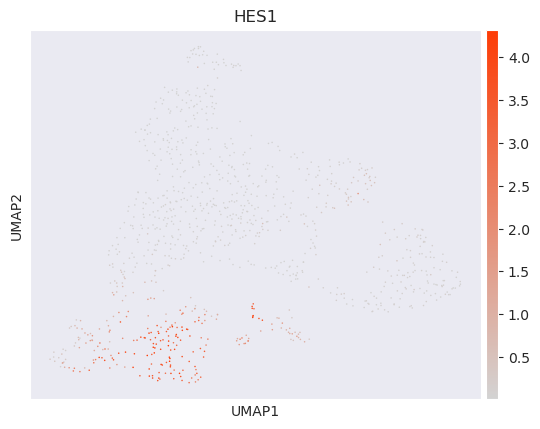

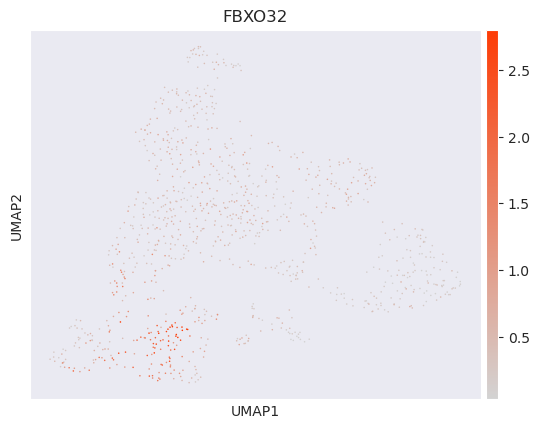

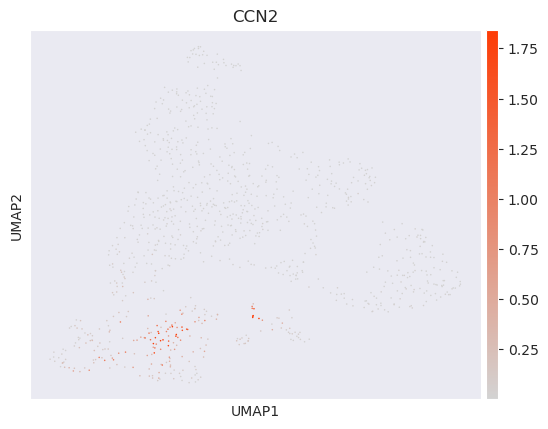

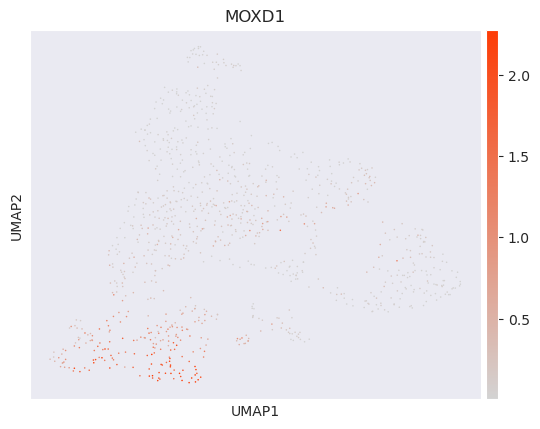

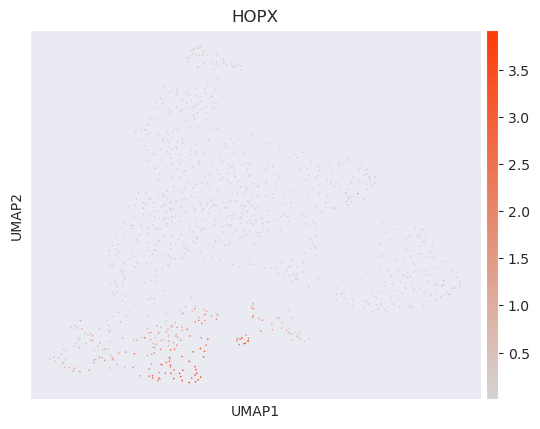

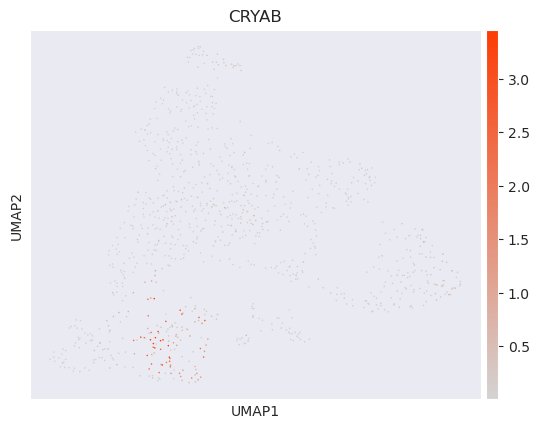

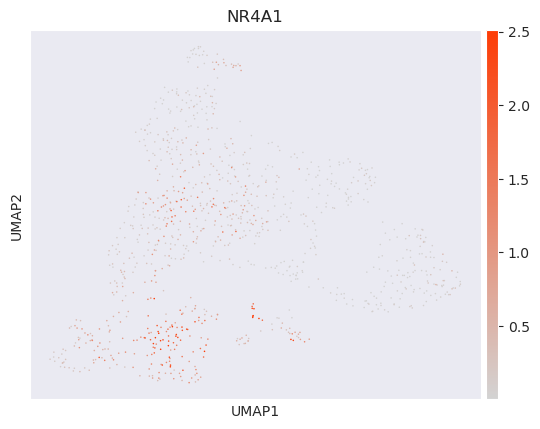

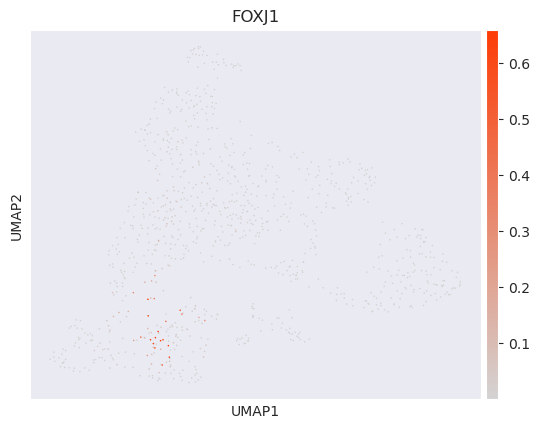

In [10]:
# cycling cells (Cycling: TOP2A, MKI67)

# radial glia (RG: SOX9, HES1)
## includes ventricular radial glia (vRG: FBXO32, CCN2/CTGF) 
## includes outer radial glia (oRG: MOXD1, HOPX)
## these were separated according to time (early RG, PCW16: NPY, FGFR3; late RG, PCW20–24: CD9, GPX3)
## includes truncated RG (tRG) and ependymal cells (tRG: CRYAB, NR4A1, FOXJ1)

markers = ['TOP2A','MKI67',
           'SOX9','HES1',
           'FBXO32','CCN2',
           'MOXD1','HOPX',
           'CRYAB','NR4A1','FOXJ1']
sc.pl.dotplot(adata, markers, groupby='leiden_scvi')
PlotUMAP(adata, markers, layer='log2_counts_scvi', size=5)

In [11]:
# A cluster of multipotent glial progenitor cells (mGPC) expressed genes associated with both RGs and oligodendrocyte precursors (mGPC: ASCL1, OLIG2, PDGFRA, EGFR).
# This cluster was different from the OPC/Oligo cluster that expressed SOX10, NKX2.2, and MBP.
# Genes associated with astrocyte identity (AQP4, APOE) were observed in the mGPC cluster as well as in the late RG cluster.
# oligodendrocyte progenitor cell and oligodendrocyte (OPC/Oligo: SOX10, NKX2-2/NKX2.2, MBP)

markers = ['ASCL1','OLIG2','PDGFRA','EGFR','AQP4','APOE',
           'SOX10','NKX2-2','MBP']
sc.pl.dotplot(adata, markers, groupby='leiden_scvi')
PlotUMAP(adata, markers, layer='log2_counts_scvi', size=5)

KeyError: "Could not find keys '['SOX10']' in columns of `adata.obs` or in adata.var_names."

In [ ]:
# intermediate progenitor cell (IPC: EOMES, PPP1R17, NEUROG1)
# glutamatergic neuron (GluN: BCL11B/CTIP2, SATB2, SLC17A7/VGLUT1)
## includes callosal projection neurons (CPN: SATB2 and not CTIP2)
## GluNs that are not CPNs are subcerebral projection neurons (SCPN)
## includes cells expressing subplate markers (SP: NR4A2, CRYM)

markers = ['EOMES','PPP1R17','NEUROG1',
           'BCL11B','SATB2','SLC17A7',
           'NR4A2','CRYM']
sc.pl.dotplot(adata, markers, groupby='leiden_scvi')
PlotUMAP(adata, markers, layer='log2_counts_scvi', size=5)

In [ ]:
# interneuron (IN: DLX2, GAD2)
## one cluster expressed markers associated with medial ganglionic eminence (MGE: LHX6, SST)
## the other cluster expressed markers associated with both caudal ganglionic eminence and pallial-subpallial boundary (CGE: SP8, NR2F2; PSB: MEIS2, ETV1)

markers = ['DLX2','GAD2',
           'LHX6','SST',
           'SP8','NR2F2','MEIS2','ETV1']
sc.pl.dotplot(adata, markers, groupby='leiden_scvi')
PlotUMAP(adata, markers, layer='log2_counts_scvi', size=5)

In [ ]:
# microglia (MG: AIF1, CCL3)
# endothelial cells (EC: CLDN5, PECAM1)
# pericytes (Peric: FOXC2, PDGFRB, HOPX)
# vascular leptomeningeal cells (VLMC: FOXC2, COL1A1, LUM, CRYAB, EGFR)
# red blood cells (RBC: HEMGN)
markers = ['AIF1','CCL3',
           'CLDN5','PECAM1',
           'FOXC2','PDGFRB','HOPX',
           'COL1A1','LUM','CRYAB','EGFR',
           'HEMGN']
sc.pl.dotplot(adata, markers, groupby='leiden_scvi')
PlotUMAP(adata, markers, layer='log2_counts_scvi', size=5)

In [ ]:
cluster_labels = {'0':'IN MGE',
                  '1':'IN CGE',
                  '2':'GluN CPN',
                  '3':'GluN SCPN',
                  '4':'GluN SCPN',
                  '5':'GluN SCPN',
                  '6':'GluN SCPN',
                  '7':'GluN SCPN',
                  '8':'GluN SCPN',
                  '9':'GluN CPN/SCPN',
                  '10':'vRG',
                  '11':'GluN SCPN',
                  '12':'IPC',
                  '13':'mGPC',
                  '14':'GluN SCPN',
                  '15':'GluN SCPN',
                  '16':'GluN SCPN',
                  '17':'IN CGE',
                  '18':'oRG',
                  '19':'IPC',
                  '20':'GluN CPN',
                  '21':'GluN CPN',
                  '22':'oRG',
                  '23':'GluN SCPN',
                  '24':'vRG/oRG',
                  '25':'oRG',
                  '26':'OPC/Oligo',
                  '27':'GluN CPN',
                  '28':'SP',
                  '29':'GluN SCPN',
                  '30':'oRG',
                  '31':'GluN CPN',
                  '32':'GluN CPN',
                  '33':'IN CGE/MGE',
                  '34':'GluN SCPN',
                  '35':'tRG',
                  '36':'IN CGE/MGE',
                  '37':'MG',
                  '38':'MG',
                  '39':'Pericyte',
                  '40':'GluN SCPN',
                  '41':'vRG',
                  '42':'GluN CPN',
                  '43':'IN MGE',
                  '44':'EC',
                  '45':'vRG/oRG',
                  '46':'GluN CPN/SCPN',
                  '47':'GluN CPN/SCPN',
                  '48':'IN CGE',
                  '49':'IN MGE',
                  '50':'VLMC',
                  '51':'Unknown',
                  '52':'RBC'}
adata.obs['CellType'] = adata.obs['leiden_scvi'].map(cluster_labels)
sc.pl.umap(adata, color=['CellType'], size=5, legend_loc='on data', legend_fontsize=7)

In [ ]:
# save output
adata.write(cwd+'/outs/231227_trevino_rna_scvi.h5ad')

In [ ]:
markers = ['FOXG1','CRYAB','AQP4','EGFR',
           'OLIG2','SOX10',
           'HES5','HOPX','MOXD1','TOP2A',
           'ASCL1', 'EOMES', 'NEUROG2', 'NEUROD2','BCL11B','SATB2','DLX2','LHX6','SP8','CLDN5',
           'PECAM1','FOXC2','AIF1']
sc.pl.dotplot(adata, markers, groupby='CellType')